# Kaggle Classical Baseline

This notebook trains and evaluates classical machine learning models on the Kaggle Human-LLM 
Generated Phishing/Legitimate Emails dataset. It uses TF-IDF vectorisation with Logistic 
Regression, Multinomial Naive Bayes, Linear SVC, and Random Forest classifiers. Results are 
evaluated overall and broken down by email source (human-generated vs LLM-generated) for 
comparison with the MeAJOR classical baseline.

## 1. Import Libraries
Import all libraries needed for loading data, vectorising text, training classifiers, 
and evaluating results.

In [1]:
# Standard library for working with file paths
from pathlib import Path

# pandas for loading and manipulating tabular data
import pandas as pd

# numpy for numerical operations
import numpy as np

# Standard library for timing inference
import time

# TF-IDF converts raw text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# The four classical classifiers we will evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Tools for evaluating model performance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# matplotlib for plotting confusion matrices
import matplotlib.pyplot as plt

# warnings to suppress non-critical sklearn output
import warnings
warnings.filterwarnings("ignore")

## 2. Load Processed Data
Load the train and test Parquet files produced by `kaggle_preparation.ipynb`. These files 
contain the cleaned, deduplicated `text`, `label`, and `source` columns only.

In [2]:
# Path to the folder where the processed Kaggle parquet files were saved
data_dir = Path("../data/processed/kaggle/")

# Load the 60% training split
train_df = pd.read_parquet(data_dir / "kaggle_train_60.parquet")

# Load the 40% test split
test_df = pd.read_parquet(data_dir / "kaggle_test_40.parquet")

print(f"Train size: {len(train_df)} rows")
print(f"Test size:  {len(test_df)} rows")
print(f"\nColumns: {train_df.columns.tolist()}")

Train size: 1435 rows
Test size:  957 rows

Columns: ['text', 'label', 'source']


## 3. Inspect Loaded Data
A quick check to confirm the data loaded correctly, the label distribution is preserved, 
and both sources are represented in each split.

In [3]:
# Preview the first few rows to confirm structure looks correct
train_df.head(3)

,text,label,source
0,Rachel Thompson COVID-19 Vaccination Team,1,llm-generated
1,Notification: jose@monkey.org Dear jose To c...,1,human-generated
2,ActiveState evaluation license for Komodo IDE ...,0,human-generated


In [4]:
# Check label balance is consistent with the full dataset (~56% legit, ~44% phishing)
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

Train label distribution:
label
0    1034
1     401
Name: count, dtype: int64

Test label distribution:
label
0    690
1    267
Name: count, dtype: int64


In [5]:
# Confirm both human and LLM sources are present in each split
print("Train source breakdown:")
print(train_df["source"].value_counts())
print()
print("Test source breakdown:")
print(test_df["source"].value_counts())

Train source breakdown:
source
human-generated    762
llm-generated      673
Name: count, dtype: int64

Test source breakdown:
source
llm-generated      489
human-generated    468
Name: count, dtype: int64


## 4. Prepare Features and Labels
Separate the text (features) from the label (target) for both splits. The `source` column 
is kept separately for the per-source evaluation in Section 7.

In [6]:
# X = the input text the model learns from; y = the label it tries to predict
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

# Keep source column aside for breakdown analysis later
source_test = test_df["source"]

print(f"X_train: {X_train.shape[0]} samples")
print(f"X_test:  {X_test.shape[0]} samples")

X_train: 1435 samples
X_test:  957 samples


## 5. TF-IDF Vectorisation
TF-IDF (Term Frequency–Inverse Document Frequency) converts each email's text into a 
numerical vector. Words that appear frequently in one email but rarely across all emails 
receive a higher weight. I'll fit the vectoriser on training data only to prevent data leakage.

In [7]:
# max_features limits the vocabulary to the 50,000 most frequent terms
# ngram_range=(1,2) includes both single words and two-word phrases
# sublinear_tf applies log scaling to term frequencies to reduce the impact of very common words
vectoriser = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)

# fit_transform learns the vocabulary from training data and transforms it in one step
X_train_tfidf = vectoriser.fit_transform(X_train)

# transform applies the already-fitted vocabulary to the test data — no fitting here
X_test_tfidf = vectoriser.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (1435, 50000)
TF-IDF matrix shape (test):  (957, 50000)


## 6. Train and Evaluate Classifiers
Train four classical classifiers on the TF-IDF features and evaluate each on the test set. 
For each model I'll print a classification report showing precision, recall, and F1-score for 
both classes, and display a confusion matrix.

In addition to standard accuracy and F1, this section records **inference time** and 
**False Positive Rate (FPR)** for each model. Prior work (Sonesson & Jakobsson 2025) 
reported only accuracy and F1, but these two metrics are critical for real-world deployment: 
inference time determines whether a model can classify emails in real time, and FPR measures 
how often legitimate emails are incorrectly flagged as phishing — a key user-experience concern.


  TF-IDF + MultinomialNB
  Inference time: 0.0009s
                precision    recall  f1-score   support

Legitimate (0)       0.84      1.00      0.91       690
  Phishing (1)       1.00      0.51      0.67       267

      accuracy                           0.86       957
     macro avg       0.92      0.75      0.79       957
  weighted avg       0.88      0.86      0.85       957

  False Positive Rate (FPR): 0.0000


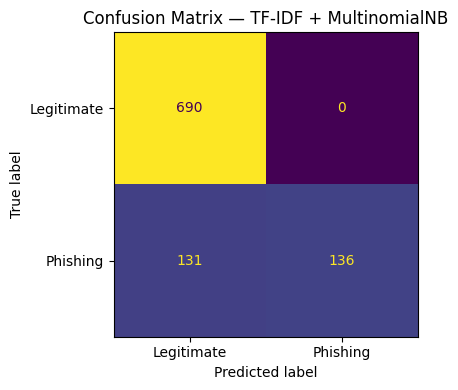


  TF-IDF + LogisticRegression
  Inference time: 0.0003s
                precision    recall  f1-score   support

Legitimate (0)       0.92      1.00      0.96       690
  Phishing (1)       1.00      0.79      0.88       267

      accuracy                           0.94       957
     macro avg       0.96      0.90      0.92       957
  weighted avg       0.95      0.94      0.94       957

  False Positive Rate (FPR): 0.0000


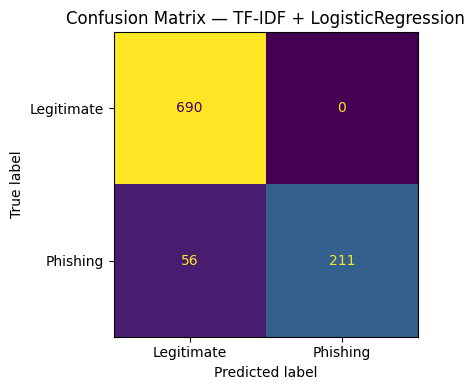


  TF-IDF + LinearSVM
  Inference time: 0.0003s
                precision    recall  f1-score   support

Legitimate (0)       0.99      1.00      0.99       690
  Phishing (1)       1.00      0.97      0.98       267

      accuracy                           0.99       957
     macro avg       0.99      0.98      0.99       957
  weighted avg       0.99      0.99      0.99       957

  False Positive Rate (FPR): 0.0014


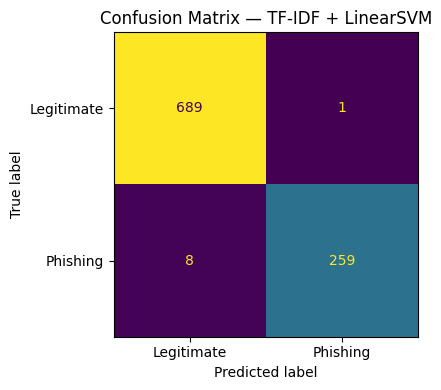


  TF-IDF + RandomForest
  Inference time: 0.0241s
                precision    recall  f1-score   support

Legitimate (0)       0.98      1.00      0.99       690
  Phishing (1)       1.00      0.94      0.97       267

      accuracy                           0.98       957
     macro avg       0.99      0.97      0.98       957
  weighted avg       0.98      0.98      0.98       957

  False Positive Rate (FPR): 0.0014


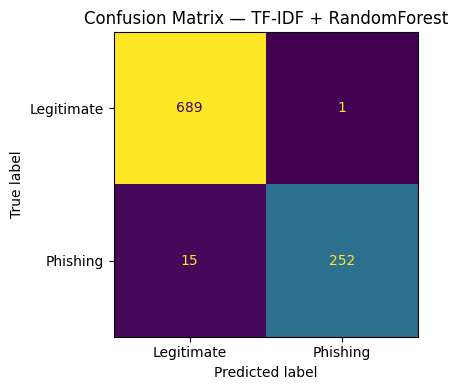

In [8]:
# Create the figures folder for saving confusion matrix images
figures_dir = Path("../results/figures/")
figures_dir.mkdir(parents=True, exist_ok=True)

from sklearn.metrics import accuracy_score, f1_score

# Define all four classifiers (including Random Forest as the 4th)
models = {
    "TF-IDF + MultinomialNB": MultinomialNB(),
    "TF-IDF + LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "TF-IDF + LinearSVM": LinearSVC(max_iter=2000, random_state=42),
    "TF-IDF + RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
}

# Dictionaries to store predictions and per-model metrics for use in Section 7
all_predictions = {}
results_summary = []

# Loop through each model, train it, evaluate it, and plot its confusion matrix
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # Train the model on the TF-IDF training matrix
    model.fit(X_train_tfidf, y_train)

    # Measure inference time around the predict call
    start = time.time()
    y_pred = model.predict(X_test_tfidf)
    elapsed = time.time() - start
    print(f"  Inference time: {elapsed:.4f}s")

    # Store predictions so we can use them in the per-source breakdown
    all_predictions[name] = y_pred

    # Print precision, recall, F1-score and support for each class
    print(classification_report(y_test, y_pred, target_names=["Legitimate (0)", "Phishing (1)"]))

    # Build the confusion matrix for this model
    cm = confusion_matrix(y_test, y_pred)

    # Compute False Positive Rate: legitimate emails wrongly flagged as phishing
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    print(f"  False Positive Rate (FPR): {fpr:.4f}")

    # Store summary metrics for the results table in Section 7
    results_summary.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 (Phishing)": round(f1_score(y_test, y_pred, pos_label=1), 4),
        "FPR": round(fpr, 4),
        "Inference Time (s)": round(elapsed, 4),
    })

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()

    # Save the confusion matrix image to the figures folder
    plt.savefig(figures_dir / f"kaggle_cm_{name.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

## 7. Summary Results Table
A clean side-by-side comparison of all four models on the key deployment-relevant metrics: 
overall accuracy, F1-score on the phishing class, False Positive Rate, and inference time. 
This table is the primary reference for the final report and directly extends the metrics 
reported by Sonesson & Jakobsson (2025), who recorded only accuracy and F1.

In [9]:
# Build the summary DataFrame from metrics collected during the evaluation loop
summary_df = pd.DataFrame(results_summary, columns=["Model", "Accuracy", "F1 (Phishing)", "FPR", "Inference Time (s)"])

print(summary_df.to_string(index=False))

                      Model  Accuracy  F1 (Phishing)    FPR  Inference Time (s)
     TF-IDF + MultinomialNB    0.8631         0.6749 0.0000              0.0009
TF-IDF + LogisticRegression    0.9415         0.8828 0.0000              0.0003
         TF-IDF + LinearSVM    0.9906         0.9829 0.0014              0.0003
      TF-IDF + RandomForest    0.9833         0.9692 0.0014              0.0241


## 8. Per-Source Breakdown
Evaluate each model separately on human-generated and LLM-generated emails. This reveals 
whether models generalise equally across both sources or perform better on one type，  which 
would suggest the model is exploiting writing style rather than genuine phishing cues.

In [10]:
# Create boolean masks to filter test rows by source
human_mask = source_test.values == "human-generated"
llm_mask   = source_test.values == "llm-generated"

for name, y_pred in all_predictions.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # Evaluate only on human-generated test rows
    print("  >> Human-generated emails:")
    print(classification_report(
        y_test[human_mask], y_pred[human_mask],
        target_names=["Legitimate (0)", "Phishing (1)"],
        zero_division=0
    ))

    # Evaluate only on LLM-generated test rows
    print("  >> LLM-generated emails:")
    print(classification_report(
        y_test[llm_mask], y_pred[llm_mask],
        target_names=["Legitimate (0)", "Phishing (1)"],
        zero_division=0
    ))


  TF-IDF + MultinomialNB
  >> Human-generated emails:
                precision    recall  f1-score   support

Legitimate (0)       0.80      1.00      0.89       266
  Phishing (1)       1.00      0.66      0.80       202

      accuracy                           0.85       468
     macro avg       0.90      0.83      0.84       468
  weighted avg       0.88      0.85      0.85       468

  >> LLM-generated emails:
                precision    recall  f1-score   support

Legitimate (0)       0.87      1.00      0.93       424
  Phishing (1)       1.00      0.03      0.06        65

      accuracy                           0.87       489
     macro avg       0.94      0.52      0.50       489
  weighted avg       0.89      0.87      0.82       489


  TF-IDF + LogisticRegression
  >> Human-generated emails:
                precision    recall  f1-score   support

Legitimate (0)       0.88      1.00      0.94       266
  Phishing (1)       1.00      0.82      0.90       202

      accu

## 9. Results Summary (CSV Export)
Compile the overall accuracy and macro-averaged F1-score for each model into a single 
table for easy comparison with the MeAJOR classical baseline results.

In [11]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Create the metrics folder if it doesn't already exist
metrics_dir = Path("../results/metrics/")
metrics_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

for name, model in models.items():

    # Re-run inference and time it
    start = time.time()
    y_pred = model.predict(X_test_tfidf)
    elapsed = time.time() - start

    # Unpack confusion matrix into true/false positives and negatives
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # False positive rate = legitimate emails wrongly flagged as phishing
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    summary_rows.append({
        "dataset": "Kaggle",
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_pred), 6),
        # precision and recall computed for the phishing class only (pos_label=1)
        "precision": round(precision_score(y_test, y_pred, pos_label=1), 6),
        "recall": round(recall_score(y_test, y_pred, pos_label=1), 6),
        "f1": round(f1_score(y_test, y_pred, pos_label=1), 6),
        "false_positive_rate": round(fpr, 6),
        "inference_time_total_sec": round(elapsed, 6),
        # Per-email time = total divided by number of test emails
        "inference_time_per_email_sec": round(elapsed / len(y_test), 9),
        "train_rows": len(y_train),
        "test_rows": len(y_test),
        # vocab_size = number of unique terms the TF-IDF vectoriser learned
        "vocab_size": len(vectoriser.vocabulary_),
    })

# Display the completed summary table
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string())

# Save to CSV, same column structure as MeAJOR
summary_df.to_csv(metrics_dir / "kaggle_classical_baseline_results.csv", index=False)
print("\nResults saved to ../results/metrics/kaggle_classical_baseline_results.csv")

  dataset                        model  accuracy  precision    recall        f1  false_positive_rate  inference_time_total_sec  inference_time_per_email_sec  train_rows  test_rows  vocab_size
0  Kaggle       TF-IDF + MultinomialNB  0.863114   1.000000  0.509363  0.674938             0.000000                  0.000984                  1.028000e-06        1435        957       50000
1  Kaggle  TF-IDF + LogisticRegression  0.941484   1.000000  0.790262  0.882845             0.000000                  0.000267                  2.790000e-07        1435        957       50000
2  Kaggle           TF-IDF + LinearSVM  0.990596   0.996154  0.970037  0.982922             0.001449                  0.000265                  2.770000e-07        1435        957       50000
3  Kaggle        TF-IDF + RandomForest  0.983281   0.996047  0.943820  0.969231             0.001449                  0.023528                  2.458500e-05        1435        957       50000

Results saved to ../results/metrics/kag

In [12]:
# Save the summary table to the metrics folder — matching MeAJOR's output location
metrics_dir = Path("../results/metrics/")
metrics_dir.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(metrics_dir / "kaggle_classical_baseline_results.csv")
print("Results saved to ../results/metrics/kaggle_classical_baseline_results.csv")

Results saved to ../results/metrics/kaggle_classical_baseline_results.csv
